In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [6]:
df = pd.read_csv("Delivery_Logistics_updated.csv")
print("Dataset Shape:", df.shape)
display(df.head())
print("Columns in Dataset:")
print(df.columns.tolist())

Dataset Shape: (25000, 15)


,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,8,8,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,2,3,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,10,16,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,6,8,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,9,16,no,delivered,4,1394.5600


Columns in Dataset:
['delivery_id', 'delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'distance_km', 'package_weight_kg', 'delivery_time_hours', 'expected_time_hours', 'delayed', 'delivery_status', 'delivery_rating', 'delivery_cost']


In [8]:
print("Number of Records:", len(df))
print("Number of Columns:", len(df.columns))
print("\nMissing Values:")
display(df.isnull().sum())
print("\nDuplicate Records:", df.duplicated().sum())

Number of Records: 25000
Number of Columns: 15

Missing Values:


,0
delivery_id,0
delivery_partner,0
package_type,0
vehicle_type,0
delivery_mode,0
region,0
weather_condition,0
distance_km,0
package_weight_kg,0
delivery_time_hours,0



Duplicate Records: 0


In [10]:
target = "delivery_time_hours"
print("Target Variable:", target)

Target Variable: delivery_time_hours


In [12]:
features = [
    "delivery_partner",
    "package_type",
    "vehicle_type",
    "delivery_mode",
    "region",
    "weather_condition",
    "distance_km",
    "package_weight_kg",
    "expected_time_hours",
    "delivery_cost"
]
X = df[features].copy()
y = df[target].copy()
print("Input Features:")
print(features)
print("\nTarget:", target)

Input Features:
['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'distance_km', 'package_weight_kg', 'expected_time_hours', 'delivery_cost']

Target: delivery_time_hours


In [14]:
categorical_features = [
    "delivery_partner",
    "package_type",
    "vehicle_type",
    "delivery_mode",
    "region",
    "weather_condition"
]
numerical_features = [
    "distance_km",
    "package_weight_kg",
    "expected_time_hours",
    "delivery_cost"
]
print("Categorical Features:", categorical_features)
print("Numerical Features:", numerical_features)

Categorical Features: ['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition']
Numerical Features: ['distance_km', 'package_weight_kg', 'expected_time_hours', 'delivery_cost']


In [17]:
numerical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])
preprocessor = ColumnTransformer([
    ("num", numerical_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))

Training Records: 20000
Testing Records: 5000


In [22]:
models = {
    "Linear Regression":
        LinearRegression(),
    "Decision Tree":
        DecisionTreeRegressor(
            random_state=42
        ),
    "Random Forest":
        RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ),
    "Gradient Boosting":
        GradientBoostingRegressor(
            random_state=42
        )
}

In [24]:
results = []
trained_models = {}
for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    mae = mean_absolute_error(
        y_test,
        predictions
    )
    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )
    r2 = r2_score(
        y_test,
        predictions
    )
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })
    trained_models[name] = pipeline
results_df = pd.DataFrame(results)
display(
    results_df.sort_values(
        by="MAE"
    )
)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.283154,1.622363,0.728289
3,Gradient Boosting,1.284024,1.624280,0.727646
2,Random Forest,1.324452,1.673028,0.711053
1,Decision Tree,1.805000,2.349425,0.430184


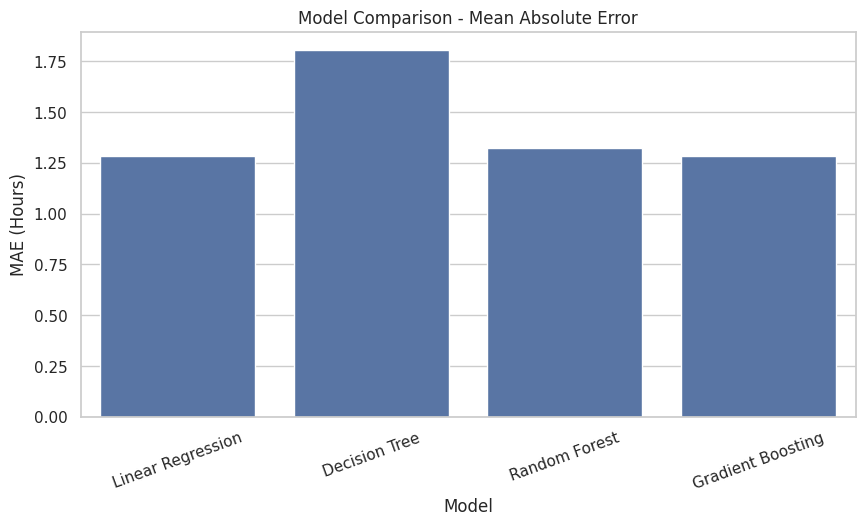

In [27]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=results_df,
    x="Model",
    y="MAE"
)
plt.title("Model Comparison - Mean Absolute Error")
plt.xlabel("Model")
plt.ylabel("MAE (Hours)")
plt.xticks(rotation=20)
plt.show()

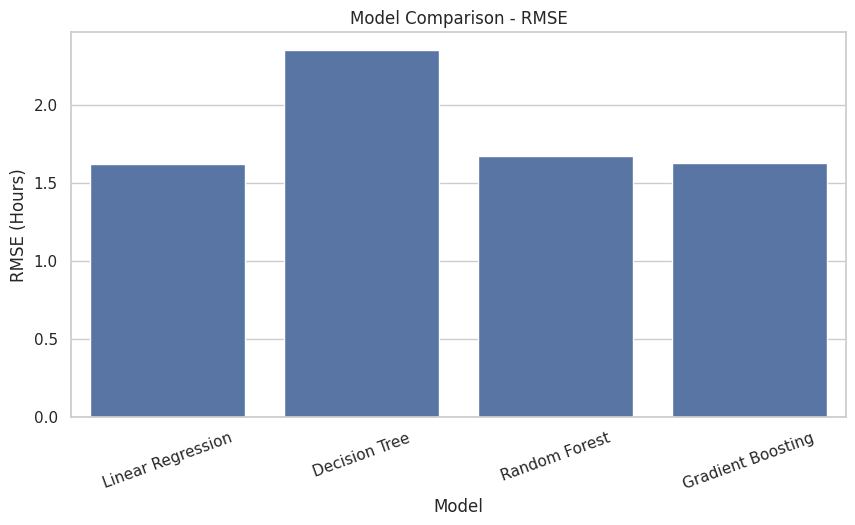

In [29]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=results_df,
    x="Model",
    y="RMSE"
)
plt.title("Model Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE (Hours)")
plt.xticks(rotation=20)
plt.show()

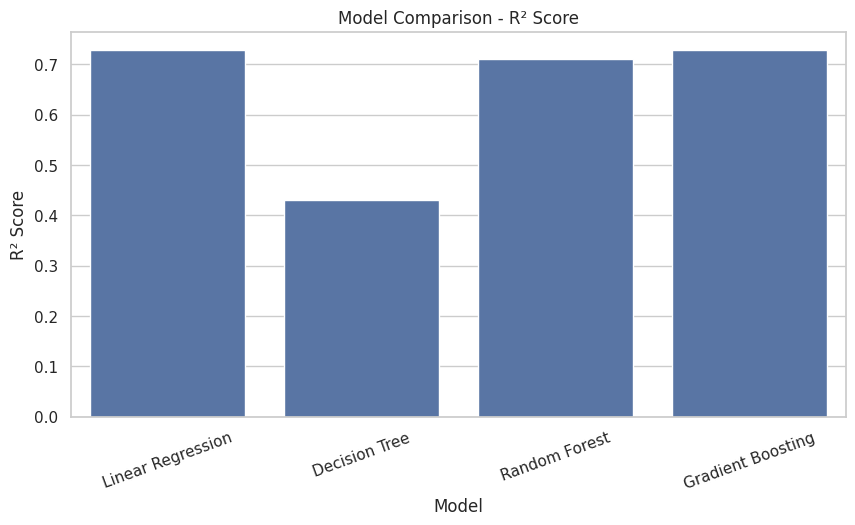

In [31]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=results_df,
    x="Model",
    y="R2 Score"
)
plt.title("Model Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=20)
plt.show()

In [33]:
best_model_name = results_df.loc[
    results_df["MAE"].idxmin(),
    "Model"
]
print("Model with Lowest MAE:")
print(best_model_name)

Model with Lowest MAE:
Linear Regression


In [35]:
selected_pipeline = trained_models[
    best_model_name
]
cv_scores = cross_val_score(
    selected_pipeline,
    X,
    y,
    cv=5,
    scoring="neg_mean_absolute_error"
)
cv_mae = -cv_scores
print("5-Fold Cross-Validation MAE:")
print(cv_mae)
print("\nAverage CV MAE:",
      cv_mae.mean())
print("Standard Deviation:",
      cv_mae.std())

5-Fold Cross-Validation MAE:
[1.26071356 1.28710693 1.28418801 1.30920572 1.27743664]

Average CV MAE: 1.2837301693372454
Standard Deviation: 0.01568431242580114


In [44]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])
param_grid = {
    "model__n_estimators": [
        100,
        150
    ],
    "model__max_depth": [
        None,
        10,
        20
    ],
    "model__min_samples_split": [
        2,
        5
    ]
}
grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)
grid_search.fit(
    X_train,
    y_train
)
print("Best Parameters:")
print(grid_search.best_params_)
print("\nBest Cross-Validation MAE:")
print(-grid_search.best_score_)

Best Parameters:
{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 150}

Best Cross-Validation MAE:
1.2955561342189925


In [46]:
tuned_model = grid_search.best_estimator_
tuned_predictions = tuned_model.predict(
    X_test
)
tuned_mae = mean_absolute_error(
    y_test,
    tuned_predictions
)
tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_predictions
    )
)
tuned_r2 = r2_score(
    y_test,
    tuned_predictions
)
print("Tuned Random Forest Performance")
print("--------------------------------")
print("MAE :", tuned_mae)
print("RMSE:", tuned_rmse)
print("R²  :", tuned_r2)

Tuned Random Forest Performance
--------------------------------
MAE : 1.2932300981644833
RMSE: 1.6364732744720036
R²  : 0.7235420693801178


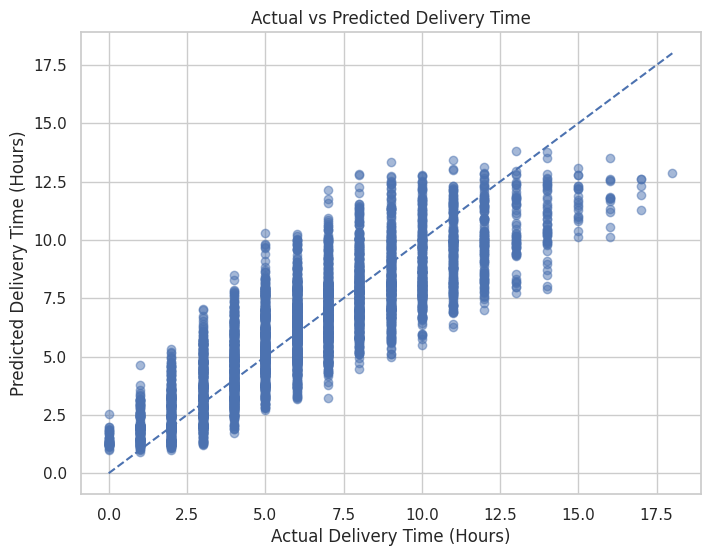

In [48]:
plt.figure(figsize=(8, 6))
plt.scatter(
    y_test,
    tuned_predictions,
    alpha=0.5
)
min_value = min(
    y_test.min(),
    tuned_predictions.min()
)
max_value = max(
    y_test.max(),
    tuned_predictions.max()
)
plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)
plt.xlabel("Actual Delivery Time (Hours)")
plt.ylabel("Predicted Delivery Time (Hours)")
plt.title(
    "Actual vs Predicted Delivery Time"
)
plt.show()

Prediction Error Summary:
count    5000.000000
mean        0.034556
std         1.636272
min        -5.305324
25%        -1.050175
50%         0.009821
75%         1.086255
max         6.084238
Name: delivery_time_hours, dtype: float64


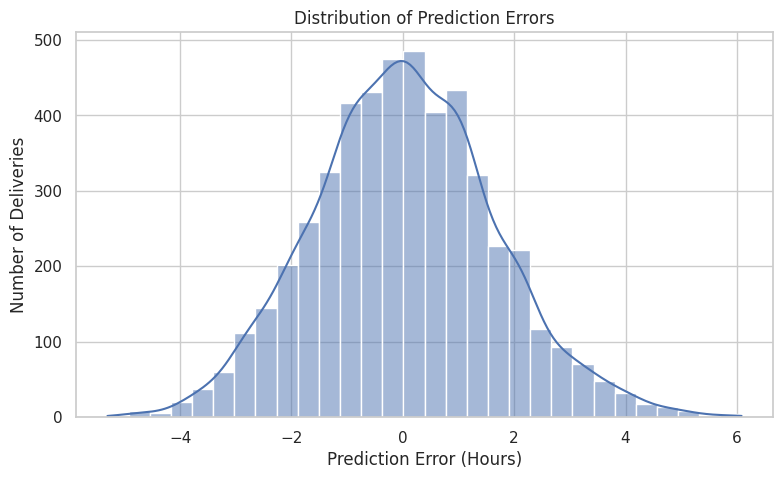

In [51]:
errors = y_test - tuned_predictions
print("Prediction Error Summary:")
print(pd.Series(errors).describe())
plt.figure(figsize=(9, 5))

sns.histplot(
    errors,
    bins=30,
    kde=True
)
plt.xlabel("Prediction Error (Hours)")
plt.ylabel("Number of Deliveries")
plt.title("Distribution of Prediction Errors")
plt.show()

,Feature,Importance
0,num__distance_km,0.592261
42,cat__weather_condition_stormy,0.170010
41,cat__weather_condition_rainy,0.112871
39,cat__weather_condition_foggy,0.045444
3,num__delivery_cost,0.028002
1,num__package_weight_kg,0.015932
2,num__expected_time_hours,0.001793
21,cat__package_type_pharmacy,0.001362
10,cat__delivery_partner_fedex,0.001211
26,cat__vehicle_type_truck,0.001204


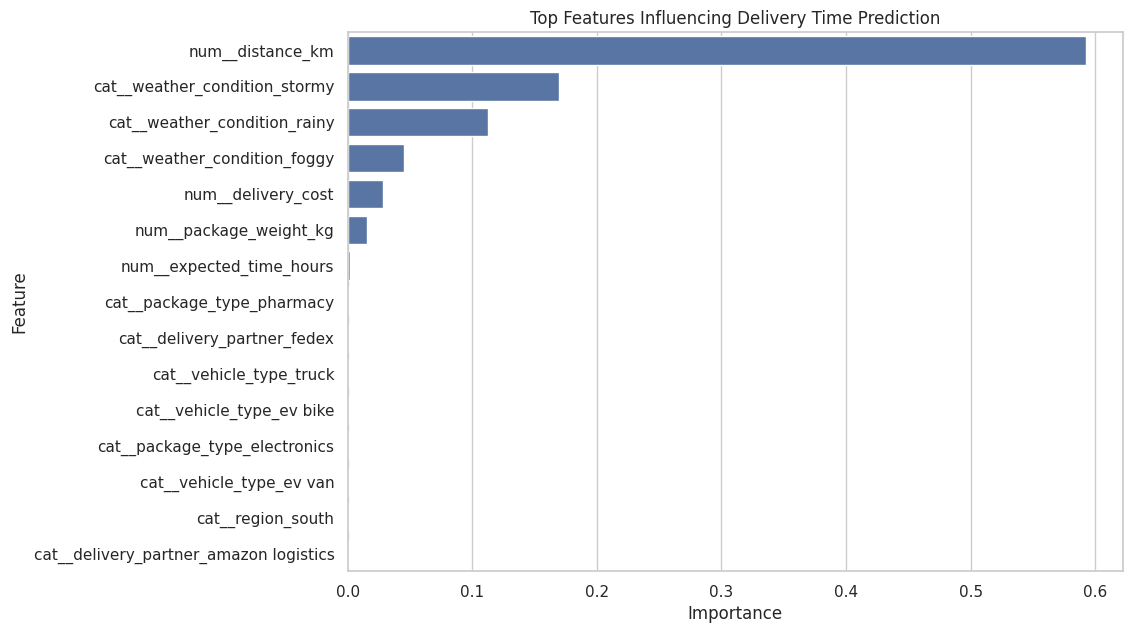

In [54]:
preprocessor_fitted = tuned_model.named_steps[
    "preprocessor"
]
rf_model = tuned_model.named_steps[
    "model"
]
feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)
importance = rf_model.feature_importances_
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
display(
    feature_importance.head(15)
)
top_features = feature_importance.head(15)
plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)
plt.title(
    "Top Features Influencing Delivery Time Prediction"
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [56]:
prediction_results = X_test.copy()
prediction_results["Actual_Delivery_Time"] = (
    y_test.values
)
prediction_results["Predicted_Delivery_Time"] = (
    tuned_predictions
)
prediction_results["Prediction_Error"] = (
    prediction_results["Actual_Delivery_Time"]
    - prediction_results["Predicted_Delivery_Time"]
)
display(
    prediction_results.head(20)
)

,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,expected_time_hours,delivery_cost,Actual_Delivery_Time,Predicted_Delivery_Time,Prediction_Error
6868,xpressbees,documents,truck,standard,central,foggy,228.6,40.83,24,1265.49,7,8.717664,-1.717664
24016,delhivery,clothing,truck,express,south,hot,121.8,18.11,4,713.33,4,4.087122,-0.087122
9668,blue dart,pharmacy,scooter,standard,west,cold,147.7,22.41,24,805.73,6,4.759594,1.240406
13640,dhl,cosmetics,bike,same day,central,stormy,126.3,31.94,8,827.32,5,8.101988,-3.101988
14018,shadowfax,automobile parts,bike,express,north,hot,165.4,38.67,5,993.01,4,5.137857,-1.137857
7488,delhivery,furniture,van,two day,east,foggy,195.1,28.40,16,1060.70,8,7.516849,0.483151
5804,ekart,electronics,truck,express,north,stormy,44.7,47.65,2,416.45,5,6.220779,-1.220779
12909,xpressbees,cosmetics,ev bike,same day,north,rainy,212.5,39.04,8,1279.62,6,8.888422,-2.888422
3386,xpressbees,furniture,bike,standard,central,stormy,128.8,11.12,24,677.36,11,8.157836,2.842164
9567,shadowfax,electronics,bike,two day,west,hot,237.3,46.99,16,1327.47,10,6.663028,3.336972


In [59]:
prediction_results["Expected_Time"] = (
    prediction_results["expected_time_hours"]
)
prediction_results["Predicted_Delay"] = (
    prediction_results["Predicted_Delivery_Time"]
    - prediction_results["Expected_Time"]
)

prediction_results["Attention_Required"] = np.where(
    prediction_results["Predicted_Delay"] > 2,
    "Yes",
    "No"
)
display(
    prediction_results[
        [
            "distance_km",
            "vehicle_type",
            "weather_condition",
            "expected_time_hours",
            "Predicted_Delivery_Time",
            "Predicted_Delay",
            "Attention_Required"
        ]
    ].head(20)
)

,distance_km,vehicle_type,weather_condition,expected_time_hours,Predicted_Delivery_Time,Predicted_Delay,Attention_Required
6868,228.6,truck,foggy,24,8.717664,-15.282336,No
24016,121.8,truck,hot,4,4.087122,0.087122,No
9668,147.7,scooter,cold,24,4.759594,-19.240406,No
13640,126.3,bike,stormy,8,8.101988,0.101988,No
14018,165.4,bike,hot,5,5.137857,0.137857,No
7488,195.1,van,foggy,16,7.516849,-8.483151,No
5804,44.7,truck,stormy,2,6.220779,4.220779,Yes
12909,212.5,ev bike,rainy,8,8.888422,0.888422,No
3386,128.8,bike,stormy,24,8.157836,-15.842164,No
9567,237.3,bike,hot,16,6.663028,-9.336972,No


In [62]:
risk_counts = prediction_results[
    "Attention_Required"
].value_counts()
display(risk_counts)

risk_percentage = (
    prediction_results[
        "Attention_Required"
    ].value_counts(normalize=True)
    * 100
)
display(risk_percentage)

,count
Attention_Required,
No,4359
Yes,641


,proportion
Attention_Required,
No,87.18
Yes,12.82


In [64]:
risk_weather = pd.crosstab(
    prediction_results["weather_condition"],
    prediction_results["Attention_Required"],
    normalize="index"
) * 100
display(risk_weather)

Attention_Required,No,Yes
weather_condition,,
clear,100.000000,0.000000
cold,100.000000,0.000000
foggy,87.958716,12.041284
hot,100.000000,0.000000
rainy,67.769608,32.230392
stormy,67.461263,32.538737


In [66]:
risk_vehicle = pd.crosstab(
    prediction_results["vehicle_type"],
    prediction_results["Attention_Required"],
    normalize="index"
) * 100
display(risk_vehicle)

Attention_Required,No,Yes
vehicle_type,,
bike,87.146226,12.853774
ev bike,87.046005,12.953995
ev van,86.185819,13.814181
scooter,83.657143,16.342857
truck,89.263421,10.736579
van,90.024038,9.975962


In [68]:
risk_region = pd.crosstab(
    prediction_results["region"],
    prediction_results["Attention_Required"],
    normalize="index"
) * 100
display(risk_region)

Attention_Required,No,Yes
region,,
central,86.192893,13.807107
east,88.650307,11.349693
north,86.530612,13.469388
south,88.877339,11.122661
west,85.844749,14.155251


In [70]:
optimization_summary = prediction_results.groupby(
    "Attention_Required"
).agg(
    Deliveries=("Attention_Required", "size"),
    Average_Distance=("distance_km", "mean"),
    Average_Expected_Time=("expected_time_hours", "mean"),
    Average_Predicted_Time=(
        "Predicted_Delivery_Time",
        "mean"
    ),
    Average_Predicted_Delay=(
        "Predicted_Delay",
        "mean"
    )
).reset_index()
display(optimization_summary)

,Attention_Required,Deliveries,Average_Distance,Average_Expected_Time,Average_Predicted_Time,Average_Predicted_Delay
0,No,4359,144.338312,14.171828,5.817386,-8.354442
1,Yes,641,182.661154,5.361934,8.895838,3.533904


In [72]:
results_df.to_csv(
    "week4_model_comparison.csv",
    index=False
)

prediction_results.to_csv(
    "week4_delivery_predictions.csv",
    index=False
)

feature_importance.to_csv(
    "week4_feature_importance.csv",
    index=False
)

optimization_summary.to_csv(
    "week4_optimization_summary.csv",
    index=False
)

print("Week 4 result files saved successfully.")

Week 4 result files saved successfully.


In [73]:
print("=" * 50)
print("WEEK 4 FINAL MODEL SUMMARY")
print("=" * 50)

print("\nBest Initial Model:")
print(best_model_name)

print("\nTuned Random Forest Results:")
print("MAE :", round(tuned_mae, 3), "hours")
print("RMSE:", round(tuned_rmse, 3), "hours")
print("R²  :", round(tuned_r2, 3))

print("\n5-Fold Cross Validation:")
print("Average MAE:",
      round(cv_mae.mean(), 3), "hours")

print("\nBest Hyperparameters:")
print(grid_search.best_params_)

print("\nTotal Test Records:",
      len(y_test))

print("=" * 50)

WEEK 4 FINAL MODEL SUMMARY

Best Initial Model:
Linear Regression

Tuned Random Forest Results:
MAE : 1.293 hours
RMSE: 1.636 hours
R²  : 0.724

5-Fold Cross Validation:
Average MAE: 1.284 hours

Best Hyperparameters:
{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 150}

Total Test Records: 5000
